# Supervised Machine Learning: Classification

## Module 1: Logistic Regression


### Lecture Notes


___

### Types of Supervised Learning

There two types of Supervised Machine Learning depending on the expected outcome. If the predicted outcome is continuous numbers, then it is referred to as Regression which we have covered in previous course. So use regression for business problems that requires prediction that explain how much. On the other hand, if the predicted outcome is categorical, then it is called Classification. We use classification for problems where the predictions relate to if a certain event will occurs, or to explain why a certain outcome occurred, e.g. detecting fraudulent transactions, whether a customer will churn, etc. With classification, the outcome is not necessarily binary such as Yes or No, True or False, but it can be more than two possible outcomes as long as the prediction belongs to a specific class. 

#### What is Needed for Classification

* Model data with:
    * Features that can be quantified (e.g. using One Hot Encoding)
    * Labels that are known (e.g. flower species type, color)

* Method to measure similarity using machine models
    * to measure past purchases
    * prediction measurement unit

#### Modeling Classification

* Examples of models/algorithms used for Classification Supervised Learning
    * Logistic Regression
    * K-Nearest Neighbors
    * Support Vector Machines
    * Neural Networks
    * Decision Tree
    * Random Forests
    * Boosting
    * Ensemble Models

* Each of the above models/algorithms can be used for both Regression and Classification

<BR>

___

<BR>


### Logistic Regression

As an example, we will look at Customer Churning for a Telecom organisation. The following figure shows the customer status after one year.

<img src="CustomerChurningClassification.png" width="30%">

The graph shows the status of the customer over a period of time where customer churn is a function of the amount of usage in minutes here. So here there is going to be one feature, the usage in minutes and a binary outcome, either they churned or they did not. 

We can treat a binary classification problem as a actual regression problem as follows. First, we encode the classes, one and zero, where one at the top indicates Customer has churned, and zero at the bottom indicates Customer has Not Churned. We can fit a best fit line as in a linear regression and fit it. With the fitted regression model we can predict a new unlabeled data and guess the outcome. We pass in the new value and with the regression coefficients, if the value is greater than 0.5, then we predict the outcome as one that churned. Otherwise, it the predicted outcome is zero, meaning no churning happened. See figure below.

<img src="CustomerChurningClassification2.png" width="30%">

What happen if our data such that the best fit line is much more heavily slated as shown below?

<img src="CustomerChurningClassification3.png" width="30%">

When we look at our 0.5 cutoff and where it lands on that line, we see that the threshold is now further to the right. So now because of the skewness to the right, the outcome will no longer be consistent as how we predicted before. This false outcome in this simple example demonstrate the limitation of using linear regression model. To overcome this we will look at the Logistic Regression model.

#### The Sigmoid Function and The Logistic Regression

This function takes the linear regression function and wraps it into its own function. The following diagram depicts the representation of the function graphically and mathematically.

<img src="TheSigmoidFunction.png" width="30%">

This function will always take values between zero and one, no matter the value of x, where x represents the full linear equation. It smooth out the effect of high and low values of x so that our algorithm is not skewed by these more extreme samples and it manages to find the obvious visual threshold. When applied to our regression model, it is called Logistic Regression. The following diagram depicts its application in our Customer Churning problem.

<img src="TheSigmoidFunction2.png" width="30%">

As opposed to Linear Regression approach, which can take on any value, here we can only take on values between 0 and 1. As a result we can now see how it can correctly classify all values on the left of our decision boundary, as well as to the right of our decision boundary.

With the one feature (i.e. usage), the boundary is just a point corresponding to y equals to 0.5, resulting in two output labels, i.e. Churned or Not Churned. See figure below.

<img src="TheLogisticRegression.png" width="30%">

With two features, we will be working with a straight line. And in general, as we move up to higher dimensions, that decision boundary will just be a hyperplane. The idea being that it is just going to be a linear function. See figure below.

<img src="TheLogisticRegression2.png" width="30%">


#### Logistic Regression with Multi-Class, Multi-Features

In a multi class classification scenario, say for example, a Three Labels (Not Churned, Cancelled, Churned) we will see that we now have a third grouping. So rather than Churned or Not Churned, we are predicting between the labels Churned, Cancelled, or Letf for a Competitor. One technique to accomplish this multi class classification is a method called One vs All. With this method, we would take one class, say Not-Churned, and that is going to be our blue dots as show in the following figure. We declare that all else is going to be our other classes. We then have our Logistic Regression that defined the decision boundary between most likely to have Churned vs All Others as shown in the figure as blue area vs gray area.

<img src="TheLogisticRegression3.png" width="30%">

We then go through the same process again for the other classes. For example in the following figure, we have Cancelled vs All Others.

<img src="TheLogisticRegression4.png" width="30%">

And then the same for the red labels, as shown below.

<img src="TheLogisticRegression5.png" width="30%">

In the end, we have each one of our three different classes where we found the Logistic Regression of one vs the rest, and end up with Logistic models splitting out three probabilities, one for each class. The estimated category is going to be the class with the highest estimated probability for each one of those, one vs all. The end result is a three separate decision boundaries as shown below.

<img src="TheLogisticRegression6.png" width="30%">


<BR><BR>




### **Logistic Regression Implementation**

**The Syntax**

```python
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(penalty='l2', c=10.0)
LR = LR.fit(X_train, y_train)

y_predict = LR.predict(X_test)

LR.coef_
```
<BR>

LogisticRegression can be instantiated with the following parameters:
*    penalty : this is the regularization type, here we specify L2 as discussed in previous module.
*    c : this is the regularization constant; here we specify 10.0; higher value = less penalty

<BR>

### **Applications for Logistic Regression**

**Customer Spending:**
* How likely is a customer is to be top  5% spender, using previous purchase data

**Customer Engagement:**
* Which customers are most likely to engage in the next 6 months

**e-Commerce:**
* Which transactions are fraudulent, using customer characteristics, location, IP addresses, etc

**Finance/Risk:**
* Predicting whether a loan will default

<BR>

**Interpretation vs Prediction**

In addition to prediction, we may want to evaluate the importance of each factor in influencing outcomes.


<BR>

___

<BR>

### **Classification Error Metrics**

Transitioning from Regression to Classification can be a bit of a head-spin because we are moving from measuring "how far off" a number is to measuring "how often" you got the label right. In Classification, being "almost right" is still an error, which is why we need more nuanced tools than just a single accuracy score.

The choice of the right error metric is highly dependant on the question and the data available. For example, say we trying to classify patients likelihood of getting leukemia. Say in our training data, a large majority of 99 percent of the patients are healthy. If we want to build a classifier and use the accuracy as our error metric, a simple model could be built that always predicts healthy, and though the model is useless, it would result in 99 percent accuracy. Thus it is very important to understand the data and choose the appropriate metric. Accuracy is often not the right metric for a binary classification problem. When thinking about errors with classification, we often talk about a **Confusion Matrix** as shown below.

<img src="ConfusionMatrix.png" width="30%">

**False Negative** is known as **Type II Error**, and **False Positive** is known as **Type I Error**. 

<BR>

### **Core Metrics**

Using the values from the Confusion Matrix, we calculate the following:

* **Accuracy**: The percentage of total guesses that were correct.
    
    $$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
    
    Caution: This is misleading if your classes are imbalanced (e.g., 99% of samples are NO).

<BR>

* **Precision**: "When the model predicts YES, how often is it right?" It focuses on the cost of False Positives.
    
    $$Precision = \frac{TP}{TP + FP}$$
    
<BR>

* **Recall (Sensitivity)**: "Out of all the actual YES cases, how many did the model find?" It focuses on the cost of False Negatives.

    $$Recall = \frac{TP}{TP + FN}$$
    
<BR>

* **Specificity**: "Out of all the actual NO cases, how many did the model correctly identify?"

    $$Specificity = \frac{TN}{TN + FP}$$

<BR><BR>


### **Thresholds and Curves**

Logistic Regression outputs a probability (between 0 and 1). To get a classification, you pick a threshold (usually 0.5). If you change that threshold, your Precision and Recall will change. Curves help you see the "big picture" of the model’s performance across all possible thresholds.

**<u>ROC Curve (Receiver Operating Characteristic)</u>**

This plots Recall (True Positive Rate) against 1 - Specificity (False Positive Rate).

*    The Goal: You want the curve to bow toward the top-left corner.

*    AUC (Area Under Curve): A single number from 0 to 1. An AUC of 0.8 means there is an 80% chance the model will rank a random positive instance higher than a random negative one.

**<u>Precision-Recall (PR) Curve</u>**

This plots Precision against Recall.

*    When to use: Use this when you have a significant class imbalance (e.g., detecting a rare disease).

*    The Goal: You want the curve to stay as close to the top-right corner as possible (high precision and high recall simultaneously).

<BR><BR>

**Summary Table for Quick Reference**

|Metric|Primary Concern|"I care most about..."|
|---|---|---|
|Precision|False Positives|"Not calling something ""Positive"" if it isn't (Spam filters)."|
|Recall|False Negatives|"Not missing any ""Positive"" cases (Cancer screening)."|
|Accuracy|Overall Correctness|Balanced datasets where all errors are equal.|
|F1-Score|Balance|A harmonic mean of Precision and Recall.|

<BR>

#### **Implementing the Calculation of ROC and Precision-Recall Curves**

Most multi-class error metrics are similar to binary versions, they just expand elements as a sum. See figure below.

<img src="Multi-Class_Error_Metrics.png" width="30%">

The figure shows a three classification problem, and again the blue diagonal represents the true predictions by the model. Accuracy is just going to be the ratio of this diagonal over the total number of samples. There is however no directed generalization of ROC, precision-recall and the remainder of the measures. But we can look at both precision-recall, specificity, etc, for each class, as a one-vs-all approach. It is still important to pick or define the right metric for the problem at hand.

In multi-class we want to think about what is the cost of misclassifying one class as the other. What is the cost of misclassifying class 1 as class2, class 3 as class 1, etc. We will have a larger confusion matrix where we predict vs the actual values. We can pull out these confusion matrices using Python.

```python
from sklearn.metrics import accuracy_score
accuracy_value = accuracy_score(y_test, y_pred)

# Other error metrics and diagnostic tools:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve

```

<BR><BR>


<BR>

___

<BR>

## Demo Lab Introduction

We will be using the [Human Activity Recognition with Smartphones](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones) database, which was built from the recordings of study participants who carried a smartphone with an embedded inertial sensor while performing activities of daily living (ADL). The objective is to classify the activities the participants performed into one of the six following categories: walking, walking upstairs, walking downstairs, sitting, standing, and laying.

The following information is provided for each record in the dataset: 

- Triaxial acceleration from the accelerometer (total acceleration) and the estimated body acceleration 
- Triaxial Angular velocity from the gyroscope 
- A 561-feature vector with time and frequency domain variables 
- The activity label 

More information about the features are available on the website linked above.


In [1]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [2]:
import seaborn as sns, pandas as pd, numpy as np

## Question 1

Import the data and do the following:

* Examine the data types--there are many columns, so it might be wise to use value counts.
* Determine if the floating point values need to be scaled.
* Determine the breakdown of each activity.
* Encode the activity label as an integer.


In [3]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/Human_Activity_Recognition_Using_Smartphones_Data.csv"

data = pd.read_csv("data/Human_Activity_Recognition_Using_Smartphones_Data.csv", sep=',')
data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING


The data columns are all floats except for the activity label.


In [4]:
data.dtypes.value_counts()

float64    561
str          1
Name: count, dtype: int64

In [5]:
data.dtypes.tail()

angle(tBodyGyroJerkMean,gravityMean)    float64
angle(X,gravityMean)                    float64
angle(Y,gravityMean)                    float64
angle(Z,gravityMean)                    float64
Activity                                    str
dtype: object

The data are all scaled from -1 (minimum) to 1.0 (maximum).


In [6]:
data.iloc[:, :-1].min().value_counts() # select all columns except the last for the min value, then count how many in the df.

-1.0    561
Name: count, dtype: int64

In [7]:
data.iloc[:, :-1].max().value_counts() # select all columns except the last for the max value, then count how many in the df.

1.0    561
Name: count, dtype: int64

Examine the breakdown of activities; they are relatively balanced.


In [8]:
data['Activity'].value_counts() # list the different distinct values in Activity column and count its occurance

Activity
LAYING                1944
STANDING              1906
SITTING               1777
WALKING               1722
WALKING_UPSTAIRS      1544
WALKING_DOWNSTAIRS    1406
Name: count, dtype: int64

Scikit learn classifiers won't accept a sparse matrix for the prediction column. Thus, either `LabelEncoder` needs to be used to convert the activity labels to integers, or if `DictVectorizer` is used, the resulting matrix must be converted to a non-sparse array.  
Use `LabelEncoder` to fit_transform the "Activity" column, and look at 5 random values.


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Activity'] = le.fit_transform(data['Activity'])

data['Activity'].sample(5)

data['Activity'].value_counts().sort_values()


Activity
4    1406
5    1544
3    1722
1    1777
2    1906
0    1944
Name: count, dtype: int64

**Side Notes on using LabelEncoder vs One-Hot Encoding**

For the dataset used, and with Logistic Regression:
1. Features (X): Use One-Hot Encoding if they are categorical input data.
2. Target (y): Use LabelEncoder; It keeps the target as a single column, which is required for calculating the Accuracy, Precision, and Recall metrics.

<BR>

## Question 2

* Calculate the correlations between the dependent variables.
* Create a histogram of the correlation values.
* Identify those that are most correlated (either positively or negatively).


In [10]:
# Calculate the correlation values
feature_cols = data.columns[:-1] # select all columns except the last one; the last column is the 'Activity' which is the target label
corr_values = data[feature_cols].corr()

# Simplify by emptying all the data below the diagonal
tril_index = np.tril_indices_from(corr_values)

# Make the unused values NaNs
for coord in zip(*tril_index):
    corr_values.iloc[coord[0], coord[1]] = np.nan
    
# Stack the data and convert to a data frame
corr_values = (corr_values
                    .stack()
                    .to_frame()
                    .reset_index()
                    .rename(columns={'level_0':'feature1', 'level_1':'feature2', 0:'correlation'})
               )

# Get the absolute values for sorting
corr_values['abs_correlation'] = corr_values.correlation.abs()

A histogram of the absolute value correlations.


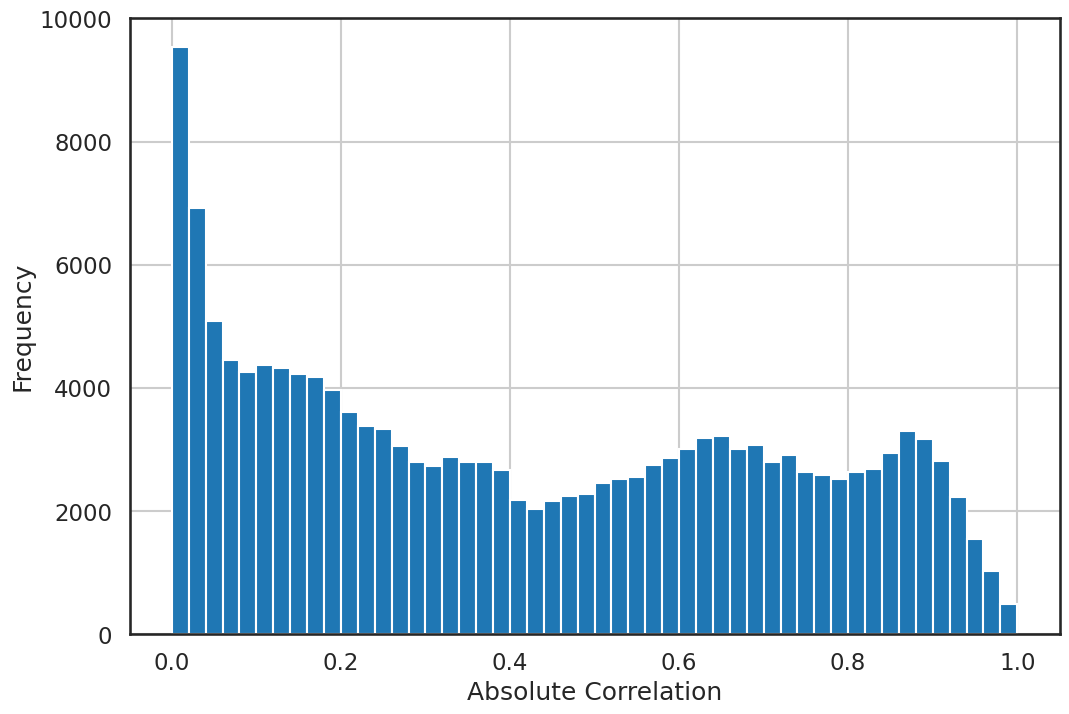

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')
sns.set_style('white')

ax = corr_values.abs_correlation.hist(bins=50, figsize=(12, 8))
ax.set(xlabel='Absolute Correlation', ylabel='Frequency');

In [12]:
# The most highly correlated values
corr_values.sort_values('correlation', ascending=False).query('abs_correlation > 0.8')

,feature1,feature2,correlation,abs_correlation
304047,fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-sma(),1.000000,1.000000
296741,fBodyBodyGyroMag-mean(),fBodyBodyGyroMag-sma(),1.000000,1.000000
119711,tGravityAccMag-mean(),tGravityAccMag-sma(),1.000000,1.000000
119157,tBodyAccMag-arCoeff()4,tGravityAccMag-arCoeff()4,1.000000,1.000000
141629,tBodyGyroJerkMag-mean(),tBodyGyroJerkMag-sma(),1.000000,1.000000
...,...,...,...,...
23560,tGravityAcc-mean()-Y,"angle(Y,gravityMean)",-0.993425,0.993425
42151,"tGravityAcc-arCoeff()-Z,3","tGravityAcc-arCoeff()-Z,4",-0.994267,0.994267
41589,"tGravityAcc-arCoeff()-Z,2","tGravityAcc-arCoeff()-Z,3",-0.994628,0.994628
24122,tGravityAcc-mean()-Z,"angle(Z,gravityMean)",-0.994764,0.994764


## Question 3

* Split the data into train and test data sets. This can be done using any method, but consider using Scikit-learn's `StratifiedShuffleSplit` to maintain the same ratio of predictor classes.
* Regardless of the method used to split the data, compare the ratio of classes in both the train and test splits.


In [13]:
from sklearn.model_selection import StratifiedShuffleSplit

# Get the split indexes
strat_shuf_split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))

# Create the dataframes
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, 'Activity']

X_test  = data.loc[test_idx, feature_cols]
y_test  = data.loc[test_idx, 'Activity']

In [14]:
y_train.value_counts(normalize=True)

Activity
0    0.188792
2    0.185046
1    0.172562
3    0.167152
5    0.149951
4    0.136496
Name: proportion, dtype: float64

In [ ]:
y_test.value_counts(normalize=True)

Activity
0    0.188673
2    0.185113
1    0.172492
3    0.167314
5    0.149838
4    0.136570
Name: proportion, dtype: float64

From the above two outputs, we can see that the y_train and y_test has about the same proportion of Activity values in their datasets.

## Question 4

* Fit a logistic regression model without any regularization using all of the features. Be sure to read the documentation about fitting a multi-class model so you understand the coefficient output. Store the model.
* Using cross validation to determine the hyperparameters and fit models using L1 and L2 regularization. Store each of these models as well. Note the limitations on multi-class models, solvers, and regularizations. The regularized models, in particular the L1 model, will probably take a while to fit.


In [16]:
from sklearn.linear_model import LogisticRegression

# Standard logistic regression
lr = LogisticRegression(solver='saga', max_iter=500).fit(X_train, y_train)
print(f"lr iterations taken: {lr.n_iter_}") # 447 @ 27s

lr iterations taken: [451]


In [ ]:
from sklearn.linear_model import LogisticRegressionCV

# L1 regularized logistic regression
lr_l1 = LogisticRegressionCV(Cs=10, cv=4, l1_ratios=(1,), use_legacy_attributes=False, solver='saga', max_iter=3500).fit(X_train, y_train)
print(f"lr_l1 iterations taken:\n{lr_l1.n_iter_}")  # 34 mins

lr_l1 iterations taken: [[[   1   13  161 1415 1337 2742 1275  552   84    9]]

 [[   1   14  215 1176 1217 2732 1487  599   71    7]]

 [[   1   15  181 1809 1252 2968 1548  667   81   10]]

 [[   1   11  204 1263 1337 3127 1962  577  108   11]]]


In [ ]:
# L2 regularized logistic regression
lr_l2 = LogisticRegressionCV(Cs=10, cv=4, l1_ratios=(0,), use_legacy_attributes=False, solver='saga', max_iter=2500).fit(X_train, y_train)
print(f"lr_l2 iterations taken:\n{lr_l2.n_iter_}") # 14 mins

lr_l2 iterations taken: [[[  33   92   17   58  228  723 1606 1709  588   92]]

 [[  32   90   18   58  231  776 1643 1798  614   97]]

 [[  32   92   19   57  227  797 1746 1842  610  100]]

 [[  32   91   17   57  229  815 1823 2004  671  113]]]


## Question 5

* Compare the magnitudes of the coefficients for each of the models. If one-vs-rest fitting was used, each set of coefficients can be plotted separately. 


In [19]:
# Combine all the coefficients into a dataframe
coefficients = list()

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

for lab,mod in zip(coeff_labels, coeff_models):
    coeffs = mod.coef_
    coeff_label = pd.MultiIndex( levels=[[lab], [0,1,2,3,4,5]], codes=[[0,0,0,0,0,0], [0,1,2,3,4,5]] )
    coefficients.append( pd.DataFrame(coeffs.T, columns=coeff_label) )

coefficients = pd.concat(coefficients, axis=1)

coefficients.sample(10)

lr                                                     l1  \
            0         1         2         3         4         5    0   
102 -0.028941  0.464386 -1.036957  0.720563 -0.844988  0.725938  0.0   
196 -0.034685 -0.444690  0.513724  0.049552 -0.179842  0.095941  0.0   
222  0.030979 -0.106183  0.123222  0.340326 -0.298144 -0.090200  0.0   
32   0.011019  0.591855 -0.574770  0.036584  0.105310 -0.169997  0.0   
538  0.143869 -0.204835  0.039101  0.342537  0.044557 -0.365228  0.0   
67  -0.015879  0.240409  0.038450  0.209031 -0.489598  0.017587  0.0   
416 -0.048255  0.042723  0.077746 -0.124066  0.139522 -0.087671  0.0   
43   0.129325  0.050239  0.151033 -0.100135 -0.160814 -0.069649  0.0   
417 -0.052682  0.005769  0.027636 -0.067317  0.086728 -0.000134  0.0   
520 -0.073009 -0.039668 -0.123470  0.043220  0.163319  0.029607  0.0   

                                                             l2            \
            1         2         3         4         5         0         1   
102  0.000000 -3.840840  4.417891 -1.396232  2.767702 -0.025731  0.974782   
196  0.000000  1.536662  0.000000  0.000000  0.000000 -0.071222 -0.616983   
222 -0.017457  0.012352  0.357722  0.000000 -0.018425  0.036699 -0.146251   
32   1.186092 -1.226962  0.000000  0.000000 -0.163922  0.006380  0.958116   
538  0.000000  0.000000  0.165369  0.000000 -0.523508  0.165192 -0.271515   
67   0.000000  0.000000  0.000000 -0.073430  0.000000 -0.016989  0.250426   
416  0.000000  0.000000  0.000000  0.000000  0.000000 -0.068936  0.037435   
43   0.000000  0.095593  0.000000  0.000000  0.000000  0.136625 -0.022871   
417  0.000000  0.000000  0.000000  0.000000  0.000000 -0.071917 -0.008214   
520  0.000000  0.000000  0.000000  0.000000  0.000000 -0.090533 -0.002667   

                                             
            2         3         4         5  
102 -1.626783  0.875251 -1.075313  0.877795  
196  0.715952  0.072159 -0.221521  0.121615  
222  0.163727  0.387984 -0.329612 -0.112547  
32  -0.934602  0.066991  0.136978 -0.233863  
538  0.099162  0.377721  0.060680 -0.431239  
67   0.077580  0.217875 -0.570107  0.041215  
416  0.079054 -0.136064  0.216437 -0.127926  
43   0.262283 -0.094141 -0.177216 -0.104681  
417  0.026609 -0.081593  0.110117  0.024998  
520 -0.185314  0.055661  0.184351  0.038502

Prepare six separate plots for each of the multi-class coefficients.


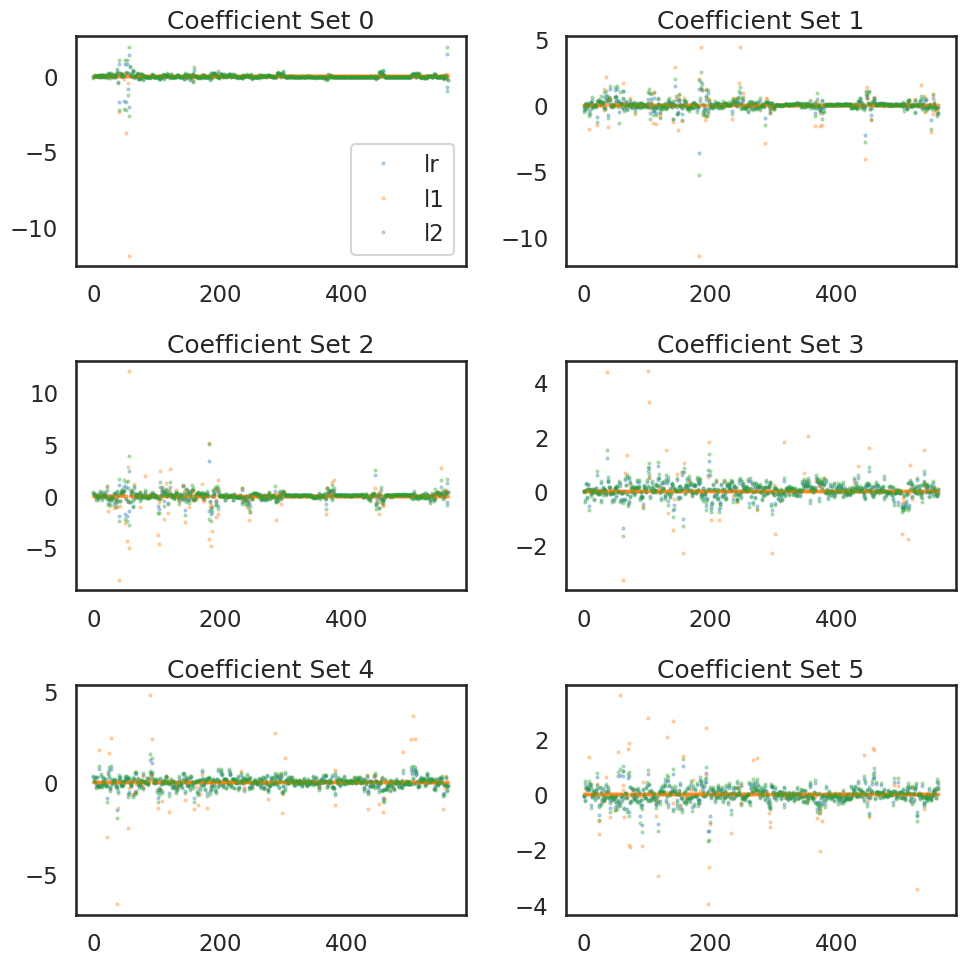

In [21]:
fig, axList = plt.subplots(nrows=3, ncols=2)
axList = axList.flatten()
fig.set_size_inches(10,10)

for ax in enumerate(axList):
    loc = ax[0]
    ax = ax[1]
    
    data = coefficients.xs(loc, level=1, axis=1)
    data.plot(marker='o', ls='', ms=2.0, ax=ax, legend=False, alpha=0.3)
    
    if ax is axList[0]:
        ax.legend(loc=4)
        
    ax.set(title='Coefficient Set '+str(loc))

plt.tight_layout()

## Question 6

* Predict and store the class for each model.
* Store the probability for the predicted class for each model. 


In [ ]:
# Predict the class and the probability for each
y_pred = list()
y_prob = list()

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

for lab,mod in zip(coeff_labels, coeff_models):
    y_pred.append(pd.Series(mod.predict(X_test), name=lab))
    y_prob.append(pd.Series(mod.predict_proba(X_test).max(axis=1), name=lab))
    
y_pred = pd.concat(y_pred, axis=1)
y_prob = pd.concat(y_prob, axis=1)

print("Y prediction as classification:")
y_pred.head()

,lr,l1,l2
0,3,3,3
1,5,5,5
2,3,3,3
3,1,1,1
4,0,0,0


From the above output, we can see that the predicted output is the same across lr, lr_l1, and lr_l2. However, there will be some prediction where they differ.

In [ ]:
print("\nPrediction that differ across different models:")
y_pred[(y_pred.lr != y_pred.l1) or (y_pred.lr != y_pred.l2) or (y_pred.l1 != y.pred.l2) ]

In [ ]:
print("\nY prediction as probability:")
y_prob.head()

,lr,l1,l2
0,0.999977,0.999998,0.999997
1,0.998302,0.999259,0.999649
2,0.996376,0.999439,0.998816
3,0.990552,0.999491,0.997661
4,0.997758,0.999571,0.999152


## Question 7

For each model, calculate the following error metrics: 

* Accuracy
* Precision
* Recall
* F-score
* Confusion Matrix

Decide how to combine the multi-class metrics into a single value for each model.


In [ ]:
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

metrics = list()
cm = dict()

for lab in coeff_labels:

    # Preciision, recall, f-score from the multi-class support function
    precision, recall, fscore, _ = score(y_test, y_pred[lab], average='weighted') # returns the averages of each score list
    
    # The usual way to calculate accuracy
    accuracy = accuracy_score(y_test, y_pred[lab])
    
    # ROC-AUC scores can be calculated by binarizing the data
    auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3,4,5]),
              label_binarize(y_pred[lab], classes=[0,1,2,3,4,5]), 
              average='weighted')
    
    # Last, the confusion matrix
    cm[lab] = confusion_matrix(y_test, y_pred[lab])
    
    metrics.append(pd.Series({'precision':precision, 'recall':recall, 
                              'fscore':fscore, 'accuracy':accuracy,
                              'auc':auc}, 
                             name=lab))

metrics = pd.concat(metrics, axis=1)

In [25]:
metrics

,lr,l1,l2
precision,0.984133,0.984132,0.983161
recall,0.984142,0.984142,0.983172
fscore,0.984135,0.984136,0.983165
accuracy,0.984142,0.984142,0.983172
auc,0.990382,0.990369,0.989787


## Question 8

* Display or plot the confusion matrix for each model.


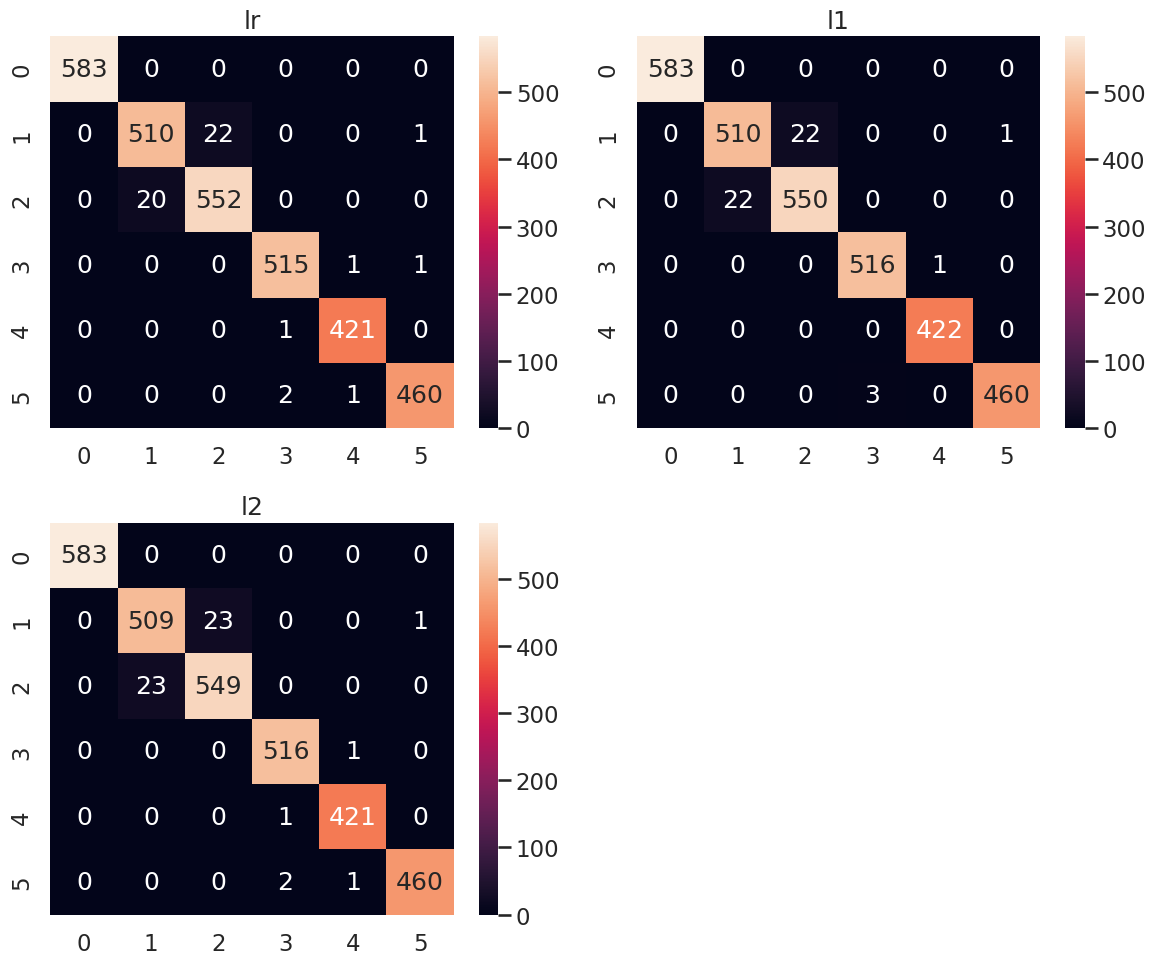

In [26]:
fig, axList = plt.subplots(nrows=2, ncols=2)
axList = axList.flatten()
fig.set_size_inches(12, 10)

axList[-1].axis('off')

for ax,lab in zip(axList[:-1], coeff_labels):
    sns.heatmap(cm[lab], ax=ax, annot=True, fmt='d');
    ax.set(title=lab);
    
plt.tight_layout()

---

### Alternate Solution to Avoid Long Run

Since the models take a very long time (1 hour 15 mins) to run. The following codes provide a way to persist the trained model objects during the first run. Subsequent run will reload these objects from files so that we can focus on the rest of the analysis. Note that we are using the Pipeline in our tasks, and we have also provide a Scaler so that the metrics are a more accurate. In addition to persisting the model objects, we also saved the LabelEncoder object in case we need to rerun with different dataset.


Loading models and encoder from storage...
                 lr        l1        l2
precision  0.983815  0.983475  0.984142
recall     0.983819  0.983495  0.984142
fscore     0.983811  0.983484  0.984134
accuracy   0.983819  0.983495  0.984142
auc        0.990180  0.990003  0.990375


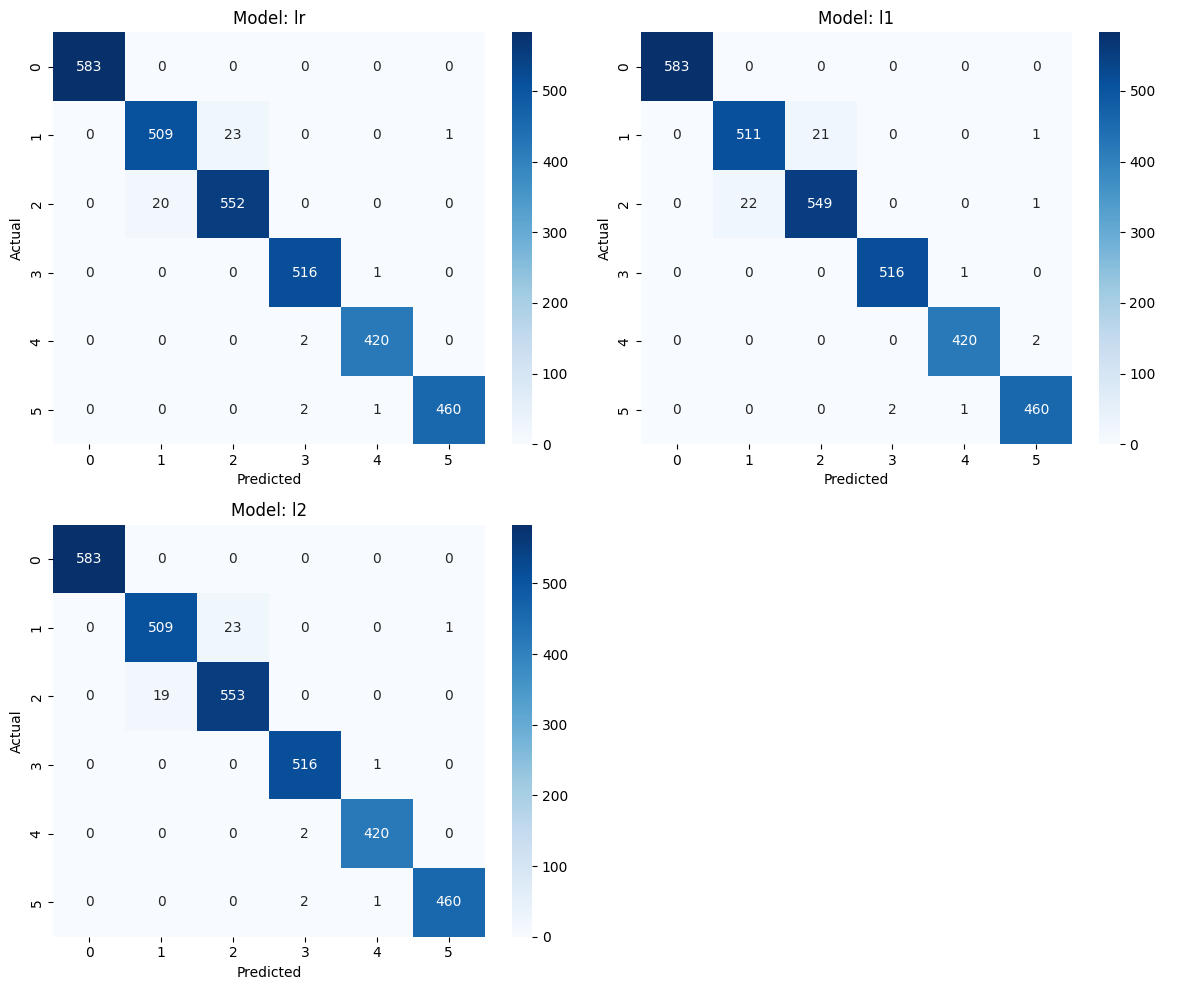

In [1]:
import seaborn as sns, pandas as pd
import matplotlib.pyplot as plt
import joblib, os
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

# 1. Setup and Persistence Configuration
MODEL_PATH = 'model_persistence/human_activity_full_package.pkl'

# Load data and initial LabelEncoding
data = pd.read_csv("data/Human_Activity_Recognition_Using_Smartphones_Data.csv")

# 2. Training/Loading Logic
if os.path.exists(MODEL_PATH):
    print("Loading models and encoder from storage...")
    storage = joblib.load(MODEL_PATH)
    le = storage['le']
    lr = storage['lr']
    lr_l1 = storage['l1']
    lr_l2 = storage['l2']
    data['Activity'] = le.transform(data['Activity'])
else:
    print("Training models... (Grab a coffee, this will take time)")
    le = LabelEncoder()
    data['Activity'] = le.fit_transform(data['Activity'])
    
    # Define Split
    feature_cols = data.columns[:-1]
    strat_shuf_split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
    train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))
    X_train, y_train = data.loc[train_idx, feature_cols], data.loc[train_idx, 'Activity']

    # Helper: Bundle Scaler + Model into a Pipeline
    def make_pipe(model_obj):
        return Pipeline([('scaler', StandardScaler()), ('model', model_obj)])

    # Fit Pipelines
    lr = make_pipe(LogisticRegression(solver='saga', max_iter=5000)).fit(X_train, y_train)
    lr_l1 = make_pipe(LogisticRegressionCV(Cs=10, cv=4, l1_ratios=(1,), use_legacy_attributes=False, solver='saga', max_iter=5000)).fit(X_train, y_train)
    lr_l2 = make_pipe(LogisticRegressionCV(Cs=10, cv=4, l1_ratios=(0,), use_legacy_attributes=False, solver='saga', max_iter=5000)).fit(X_train, y_train)

    # Save to one file
    joblib.dump({'lr': lr, 'l1': lr_l1, 'l2': lr_l2, 'le': le}, MODEL_PATH)

# 3. Predict & Generate Metrics (Always runs)
feature_cols = data.columns[:-1]
strat_shuf_split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))
X_test, y_test = data.loc[test_idx, feature_cols], data.loc[test_idx, 'Activity']

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

y_pred = pd.concat([pd.Series(m.predict(X_test), name=l) for l, m in zip(coeff_labels, coeff_models)], axis=1)

# 4. Calculation & Confusion Matrices
metrics = []
cm = {}

for lab in coeff_labels:
    precision, recall, fscore, _ = score(y_test, y_pred[lab], average='weighted')
    accuracy = accuracy_score(y_test, y_pred[lab])
    auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3,4,5]),
                        label_binarize(y_pred[lab], classes=[0,1,2,3,4,5]), average='weighted')
    cm[lab] = confusion_matrix(y_test, y_pred[lab])
    metrics.append(pd.Series({'precision':precision, 'recall':recall, 'fscore':fscore, 'accuracy':accuracy, 'auc':auc}, name=lab))

# Final Display
print(pd.concat(metrics, axis=1))

# 5. Plotting
fig, axList = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axList = axList.flatten()
axList[-1].axis('off')

for ax, lab in zip(axList[:-1], coeff_labels):
    sns.heatmap(cm[lab], ax=ax, annot=True, fmt='d', cmap='Blues')
    ax.set(title=f'Model: {lab}', xlabel='Predicted', ylabel='Actual')
plt.tight_layout()